# Python implementations of the pseudocode in Algorithms Illuminated by Tim Roughgarden (Divide & Conquer Algorithms)

## Brute Force Search for Counting Inversions - $O(n^2)$

In [1]:
def count_invers_brute_force(arr):
    invers_num = 0
    for i in range(len(arr)-1):
        for j in range(i+1, len(arr)):
            if arr[i] > arr[j]:
                invers_num += 1
    return invers_num

In [2]:
import big_o

gen = lambda n: (list(range(n, 0, -1)))

best, others = big_o.big_o(count_invers_brute_force, gen, n_repeats = 20, max_n = 800)

print(big_o.reports.big_o_report(best, others))

Best : Quadratic: time = -0.0015 + 2.6E-07*n^2 (sec)                
Constant: time = 0.064 (sec)                                    (res: 0.029)
Linear: time = -0.041 + 0.00023*n (sec)                         (res: 0.0014)
Quadratic: time = -0.0015 + 2.6E-07*n^2 (sec)                   (res: 1.8E-05)
Cubic: time = 0.014 + 3.2E-10*n^3 (sec)                         (res: 0.00068)
Polynomial: time = 1.5E-07 * x^2.1 (sec)                        (res: 2E-05)
Logarithmic: time = -0.38 + 0.075*log(n) (sec)                  (res: 0.0067)
Linearithmic: time = -0.03 + 3.4E-05*n*log(n) (sec)             (res: 0.001)
Exponential: time = 0.0028 * 1^n (sec)                          (res: 0.011)



## Counting Inversions in $O(n\log n)$ Time

In [3]:
def sort_count_inversions(arr):
    if len(arr) <= 1:
        return (arr, 0)
    else:
        mid = len(arr) // 2
        left_arr, left_count = sort_count_inversions(arr[:mid])
        right_arr, right_count = sort_count_inversions(arr[mid:])
        arr_inv, count_inv = merge_and_count(left_arr, right_arr)
        return (arr_inv, left_count+right_count+count_inv)
    
def merge_and_count(first_arr, second_arr):
    i, j, count_inv, output_arr = 0, 0, 0, []
    while i < len(first_arr) and j < len(second_arr):
        if first_arr[i] < second_arr[j]:
            output_arr.append(first_arr[i])
            i+=1
        else:
            output_arr.append(second_arr[j])
            j+=1
            count_inv = count_inv + len(first_arr) - i 
    output_arr.extend(first_arr[i:])
    output_arr.extend(second_arr[j:])
    return (output_arr, count_inv)



In [4]:
gen = lambda n: list(range(n,0,-1))

best, others = big_o.big_o(sort_count_inversions, gen, n_repeats = 20, max_n = 50000)

print(big_o.reports.big_o_report(best, others))

Best : Linearithmic: time = 0.0072 + 1.6E-06*n*log(n) (sec)         
Constant: time = 0.43 (sec)                                     (res: 0.81)
Linear: time = -0.016 + 1.8E-05*n (sec)                         (res: 0.00064)
Quadratic: time = 0.14 + 3.3E-10*n^2 (sec)                      (res: 0.048)
Cubic: time = 0.21 + 6.4E-15*n^3 (sec)                          (res: 0.13)
Polynomial: time = 7E-06 * x^1.1 (sec)                          (res: 0.00039)
Logarithmic: time = -0.75 + 0.12*log(n) (sec)                   (res: 0.33)
Linearithmic: time = 0.0072 + 1.6E-06*n*log(n) (sec)            (res: 0.00013)
Exponential: time = 0.021 * 1^n (sec)                           (res: 2.2)



## Strassen's Matrix Multiplication Algorithm 

### Brute force Approach - $O(n^3)$

In [5]:
def bruteforce_mat_mult(mat1, mat2):
    n = len(mat1)
    output_mat = [[0]*n for x in range(n)]
    for i in range(n):
        for j in range(n):
            output_mat[i][j] = 0
            for k in range(n):
                output_mat[i][j] = output_mat[i][j] + mat1[i][k]*mat2[k][j]
    return output_mat

In [6]:
import big_o, random

def make_mat(n):
    mat1 = [[random.randint(0, 9) for i in range(n)] for i in range(n)]
    mat2 = [[random.randint(0, 9) for i in range(n)] for i in range(n)]
    return (mat1, mat2)

best, others = big_o.big_o(lambda args: bruteforce_mat_mult(*args), make_mat, min_n=10, max_n=150, n_measures=10, n_repeats=5)
print(big_o.reports.big_o_report(best, others))

Best : Cubic: time = 0.00058 + 2E-07*n^3 (sec)                      
Constant: time = 0.2 (sec)                                      (res: 0.49)
Linear: time = -0.17 + 0.0046*n (sec)                           (res: 0.074)
Quadratic: time = -0.05 + 3E-05*n^2 (sec)                       (res: 0.013)
Cubic: time = 0.00058 + 2E-07*n^3 (sec)                         (res: 2E-05)
Polynomial: time = 2.3E-07 * x^3 (sec)                          (res: 3E-05)
Logarithmic: time = -0.65 + 0.21*log(n) (sec)                   (res: 0.22)
Linearithmic: time = -0.12 + 0.00089*n*log(n) (sec)             (res: 0.056)
Exponential: time = 0.0009 * 1.1^n (sec)                        (res: 1.2)



### Basic Recursive Approach - $O(n^3)$

In [7]:
def rec_mat_mult(mat1, mat2):
    if len(mat1) == 1:
        return [[mat1[0][0]*mat2[0][0]]]
    else: 
        A, B, C, D = split(mat1)
        E, F, G, H = split(mat2)

        AE, BG = rec_mat_mult(A, E), rec_mat_mult(B, G)
        AF, BH = rec_mat_mult(A, F), rec_mat_mult(B, H)
        CE, DG = rec_mat_mult(C, E), rec_mat_mult(D, G)
        CF, DH = rec_mat_mult(C, F), rec_mat_mult(D, H)

        TL, TR = add(AE, BG), add(AF, BH)
        BL, BR = add(CE, DG), add(CF, DH)

        top = [l+r for l,r in zip(TL, TR)]
        bot = [l+r for l,r in zip(BL, BR)]
        
        return top+bot

def split(mat):
    mid = len(mat)//2
    top, bot = mat[:mid], mat[mid:]
    return ([i[:mid] for i in top], [i[mid:] for i in top],
            [i[:mid] for i in bot], [i[mid:] for i in bot])

def add(p,q):
    n = len(p)
    result = [[0] * n for i in range(n)]
    for i in range(n):
        for j in range(n):
            result[i][j] = p[i][j] + q[i][j]
    return result

In [8]:
import random, time, numpy as np

sizes = [4, 8, 16, 32, 64, 128]
times = []

def make_mat_sym(n):
    size = 1 << (int(n).bit_length() - 1)
    mat1 = [[random.randint(0, 9) for x in range(size)] for x in range(size)]
    mat2 = [[random.randint(0, 9) for x in range(size)] for x in range(size)]
    return (mat1, mat2)

for size in sizes:
    m1, m2 = make_mat_sym(size)
    best_t = float('inf')
    for i in range(3):                      
        t = time.perf_counter()
        rec_mat_mult(m1, m2)
        best_t = min(best_t, time.perf_counter() - t)
    times.append(best_t)

best, others = big_o.infer_big_o_class(np.array(sizes), np.array(times))
print(big_o.reports.big_o_report(best, others))

Best : Cubic: time = -0.00022 + 3.9E-07*n^3 (sec)                   
Constant: time = 0.16 (sec)                                     (res: 0.53)
Linear: time = -0.11 + 0.0064*n (sec)                           (res: 0.068)
Quadratic: time = -0.028 + 5E-05*n^2 (sec)                      (res: 0.0081)
Cubic: time = -0.00022 + 3.9E-07*n^3 (sec)                      (res: 8.5E-07)
Polynomial: time = 3.7E-07 * x^3 (sec)                          (res: 2.9E-06)
Logarithmic: time = -0.41 + 0.18*log(n) (sec)                   (res: 0.26)
Linearithmic: time = -0.077 + 0.0013*n*log(n) (sec)             (res: 0.047)
Exponential: time = 0.00019 * 1.1^n (sec)                       (res: 3.5)



## Strassen's Algorithm - $O(n^{\log_2 7})$

In [9]:
def stras_mult(m1,m2):
    if len(m1) == 1:
        return [[m1[0][0]*m2[0][0]]]
    
    A, B, C, D = split(m1)
    E, F, G, H = split(m2)

    P1 = stras_mult(A, substract(F,H))
    P2 = stras_mult(add(A,B), H)
    P3 = stras_mult(add(C,D), E)
    P4 = stras_mult(D, substract(G,E))
    P5 = stras_mult(add(A,D), add(E,H))
    P6 = stras_mult(substract(B,D), add(G,H))
    P7 = stras_mult(substract(A,C), add(E,F))

    TL, TR = add(add(P5,P6), substract(P4,P2)),add(P1,P2)
    BL, BR = add(P3,P4), add(substract(P5,P7), substract(P1, P3))

    top = [l+r for l, r in zip(TL, TR)]
    bot = [l+r for l, r in zip(BL, BR)]
    
    return top+bot

def split(m):
    mid = len(m)//2
    top, bot = m[:mid], m[mid:]
    return ([i[:mid] for i in top], [i[mid:] for i in top],
            [i[:mid] for i in bot], [i[mid:] for i in bot])

def add(m1, m2):
    n = len(m1)
    output_mat = [[0]*n for num in range(n)]
    for i in range(n):
        for j in range(n):
            output_mat[i][j] = m1[i][j] + m2[i][j]
    return output_mat

def substract(m1, m2):
    n = len(m1)
    output_mat = [[0]*n for num in range(n)]
    for i in range(n):
        for j in range(n):
            output_mat[i][j] = m1[i][j] - m2[i][j]
    return output_mat

In [10]:
sizes = [4, 8, 16, 32, 64, 128]
times = []

for size in sizes:
    m1, m2 = make_mat_sym(size)
    best_t = float('inf')
    for i in range(3):                      
        t = time.perf_counter()
        stras_mult(m1, m2)
        best_t = min(best_t, time.perf_counter() - t)
    times.append(best_t)

best, others = big_o.infer_big_o_class(np.array(sizes), np.array(times))
print(big_o.reports.big_o_report(best, others))

Best : Cubic: time = 0.0038 + 4.8E-07*n^3 (sec)                     
Constant: time = 0.2 (sec)                                      (res: 0.82)
Linear: time = -0.14 + 0.008*n (sec)                            (res: 0.097)
Quadratic: time = -0.031 + 6.2E-05*n^2 (sec)                    (res: 0.0096)
Cubic: time = 0.0038 + 4.8E-07*n^3 (sec)                        (res: 0.00016)
Polynomial: time = 9.6E-07 * x^2.9 (sec)                        (res: 0.00078)
Logarithmic: time = -0.51 + 0.23*log(n) (sec)                   (res: 0.38)
Linearithmic: time = -0.093 + 0.0016*n*log(n) (sec)             (res: 0.065)
Exponential: time = 0.00037 * 1.1^n (sec)                       (res: 4.7)



## 1D Closest Pair - $O(n^2)$

In [11]:
import math

def oned_closest(arr):
    smallest_distance = math.inf
    for i in range(len(arr) - 1):
        j = i+1
        while j < len(arr):
            if abs(arr[i] - arr[j]) < smallest_distance:
                smallest_distance = abs(arr[i] - arr[j])
            j += 1
    return smallest_distance

oned_closest([1,4,9])

3

## 1D Closest Pair - $O(n\log n)$

In [12]:
import math

def mergesort(arr):
    if len(arr) <= 1:
        return arr
    else:
        mid = len(arr)//2
        arr1 = mergesort(arr[:mid])
        arr2 = mergesort(arr[mid:])
        sorted_arr = merge(arr1,arr2)
        return sorted_arr

def merge(arr1,arr2):
    arr = []
    i,j = 0,0
    while i < len(arr1) and j < len(arr2):
        if arr1[i] < arr2[j]:
            arr.append(arr1[i])
            i+=1
        else:
            arr.append(arr2[j])
            j+=1
    arr.extend(arr1[i:])
    arr.extend(arr2[j:])
    return arr

def closest_pair(arr):
    sorted_arr = mergesort(arr)
    minimum_distance = math.inf
    i = 0
    while i < len(sorted_arr) - 1:
        if sorted_arr[i+1] - sorted_arr[i] < minimum_distance and sorted_arr[i+1] - sorted_arr[i] > 0:
            minimum_distance = sorted_arr[i+1] - sorted_arr[i]
        i+=1
    if minimum_distance == math.inf:
        print("Empty arr or it consists only of one unique value")
        return 0
    else:
        return minimum_distance
            

In [13]:
gen = lambda n: list(range(2*n, 0, -2))

best,others = big_o.big_o(closest_pair, gen, n_repeats=20, min_n=5000)

print(big_o.reports.big_o_report(best,others))


Best : Linearithmic: time = 0.011 + 1.4E-06*n*log(n) (sec)          
Constant: time = 0.8 (sec)                                      (res: 2.4)
Linear: time = -0.038 + 1.6E-05*n (sec)                         (res: 0.0018)
Quadratic: time = 0.27 + 1.4E-10*n^2 (sec)                      (res: 0.12)
Cubic: time = 0.4 + 1.4E-15*n^3 (sec)                           (res: 0.33)
Polynomial: time = 7.5E-06 * x^1.1 (sec)                        (res: 0.00042)
Logarithmic: time = -4.5 + 0.5*log(n) (sec)                     (res: 0.39)
Linearithmic: time = 0.011 + 1.4E-06*n*log(n) (sec)             (res: 0.00028)
Exponential: time = 0.13 * 1^n (sec)                            (res: 0.73)



## 2D Closest Pair - Recursive Approach - 

In [14]:
def mergesort_axis(arr, axis):
    if len(arr)<=1:
        return arr
    mid = len(arr)//2
    return merge(mergesort_axis(arr[:mid], axis), mergesort_axis(arr[mid:], axis), axis)

def merge(arr1,arr2,axis):
    output = []
    i,j=0,0
    while i < len(arr1) and j < len(arr2):
        if arr1[i][axis] < arr2[j][axis]:
            output.append(arr1[i])
            i+=1
        else:
            output.append(arr2[j])
            j+=1
    output.extend(arr1[i:])
    output.extend(arr2[j:])
    return output


Px = mergesort_axis(points, 0)
Py = mergesort_axis(points, 1)

def sq_dist(p,q):
    dx=p[0] - q[0]
    dy=p[1] - q[1]
    return dx*dx + dy*dy

def min_distance_brute_force(arr):
    best, best_d = None, float('inf')
    for i in range(len(arr)-1):
        for j in range(i+1, len(arr)):
            d = sq_dist(arr[i], arr[j])
            if d < best_d:
                best, best_d = (arr[i], arr[j]), d
    return best

def closest_split_pair(px, py, best_pair):
    best = sq_dist(*best_pair)
    biggest_x = px[len(px)//2-1][0]
    sy = [p for p in py if (p[0] - biggest_x)**2 < best]

    for i in range(len(sy)-1):
        for j in range(1,min(8,len(sy)-i)):
            if sq_dist(sy[i], sy[i+j]) < best:
                best = sq_dist(sy[i], sy[i+j])
                best_pair = (sy[i], sy[i+j])
    return best_pair 

def closest_pair(px, py):
    if len(px)<=3: 
        return min_distance_brute_force(px)
    
    mid = len(px)//2
    lx, rx = px[:mid], px[mid:]

    left = set(lx)
    ly = [p for p in py if p in left]
    ry = [p for p in py if p not in left]
    
    (l1,l2) = closest_pair(lx,ly)
    (r1,r2) = closest_pair(rx,ry)    

    best = min((l1,l2), (r1,r2), key=lambda pair: sq_dist(*pair))
    return closest_split_pair(px,py,best)


NameError: name 'points' is not defined

## Exponentiation recursive calculation - $O(\log n)$

In [19]:
def fastpower(a,b):
    if b == 0:
        return 1 
    res = fastpower(a*a,b//2)
    return a*res if b % 2 else res

In [20]:
import random

def gen(n): 
    base = random.randint(100,10000)
    return(base, n)

best, others = big_o.big_o(lambda args: fastpower(*args), gen, min_n=100, max_n=10000, n_measures=20, n_repeats=20)

print(big_o.reports.big_o_report(best, others))

Best : Linearithmic: time = -0.0018 + 4E-07*n*log(n) (sec)          
Constant: time = 0.016 (sec)                                    (res: 0.0028)
Linear: time = -0.0031 + 3.7E-06*n (sec)                        (res: 0.00028)
Quadratic: time = 0.0039 + 3.4E-10*n^2 (sec)                    (res: 0.00048)
Cubic: time = 0.0071 + 3.3E-14*n^3 (sec)                        (res: 0.00081)
Polynomial: time = 3.5E-08 * x^1.5 (sec)                        (res: 0.00035)
Logarithmic: time = -0.053 + 0.0085*log(n) (sec)                (res: 0.0011)
Linearithmic: time = -0.0018 + 4E-07*n*log(n) (sec)             (res: 0.00028)
Exponential: time = 0.00072 * 1^n (sec)                         (res: 0.0054)



## Recursive finding of the max value in the unimodal array - $O(\log n)$

In [ ]:
def max_unimodal(arr, lo=0, hi=None):
    if hi is None:
        hi = len(arr) - 1

    if lo == hi:
        return arr[lo]

    mid = (lo+hi)//2

    if arr[mid] < arr[mid+1]:
        return max_unimodal(arr, mid+1, hi)
    else:
        return max_unimodal(arr, lo, mid)
    
# Additional practice

def min_unimodal(arr,l=0,r=None):
    if r == None:
        r = len(arr) - 1
    
    if l==r:
        return arr[l]
    
    mid = (l+r)//2
    
    if arr[mid] < arr[mid+1]:
        return min_unimodal(arr, l, mid)
    else:
        return min_unimodal(arr, mid+1, r)

SyntaxError: expected ':' (3715466217.py, line 4)

## Problem 3.3
"You are given a sorted asc. array $A$ of $n$ distinct integers, which can be positive, negative, or zero. You want to decide whether or not there is an index $i$ such that A[$i$] =$i$. Design the fastest algorithm you can for solving the problem."

In [74]:
# O(n) solution

def linear_index_match(arr):
    for i in range(len(arr)):
        if i == arr[i]:
            return True
    return False

print(linear_index_match([-3, -1, 1, 3, 5, 9]))

# O(log(n)) solution

def rec_index_match(arr, l=0, r=None):
    if r is None:
        r = len(arr) - 1
    
    if l==r:
        return arr[l] == l

    mid = (l+r)//2

    if arr[mid] == mid:
        return True

    if arr[mid] > mid:
        return rec_index_match(arr, l, mid)
    else:
        return rec_index_match(arr, mid+1, r)

print(rec_index_match([-3, -1, 1, 3, 5, 9]))

True
True


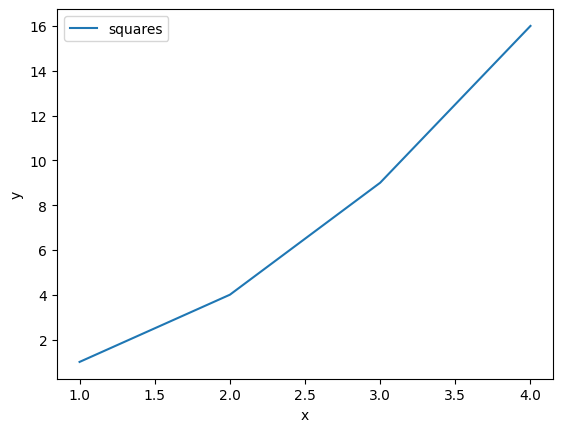

In [ ]:
import matplotlib.pyplot as plt 
import timeit
t = timeit.timeit(lambda: linear_index_match(arr), number=100)

x = [1,2,3,4]
y = [1,4,9,16]

plt.plot(x,y,label="squares")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

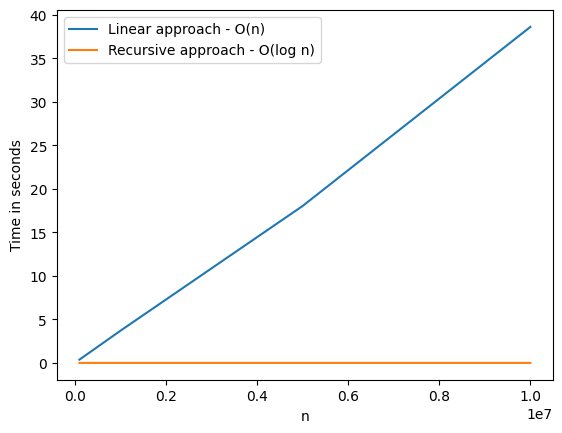

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import timeit

rng = np.random.default_rng(42)

def no_match_array(n):
    vals = rng.choice(2*n, size=n, replace=False) + n
    return np.sort(vals).tolist()

def match_array(n,k):
    arr = np.cumsum(rng.integers(1,5, size=n))
    return (arr-arr[k]+k).tolist()

sizes = [100_000, 1_000_000, 5_000_000, 10_000_000]
linear_times=[]
recursive_times=[]

for n in sizes:
    arr = no_match_array(n)
    t1 = timeit.timeit(lambda: linear_index_match(arr), number=100)
    t2 = timeit.timeit(lambda: rec_index_match(arr), number=100)
    linear_times.append(t1)
    recursive_times.append(t2)

x = sizes
a, b = linear_times, recursive_times
plt.plot(x,a,label="Linear approach - O(n)")
plt.plot(x,b,label="Recursive approach - O(log n)")
plt.xlabel("n")
plt.ylabel("Time in seconds")
plt.legend()
plt.show()
